# LEVEL: 2

## TASK: 1

Task: Restaurant Ratings
Analyze the distribution of aggregate
ratings and determine the most common
rating range.
Calculate the average number of votes
received by restaurants.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = r"C:\Users\riyap\Downloads\Dataset .csv"

df = pd.read_csv(file_path)

In [4]:
ratings  = df["Aggregate rating"].dropna()

In [5]:
range_0_2 = ratings[(ratings >= 0) & (ratings < 2)].count()
range_2_3 =  ratings[(ratings >= 2) & (ratings < 3)].count()
range_3_4 =  ratings[(ratings >= 3) & (ratings < 4)].count()
range_4_5 =  ratings[(ratings >= 4) & (ratings <= 5)].count()

In [6]:
rating_ranges = {"0-2": range_0_2, "2-3": range_2_3, "3-4": range_3_4, "4-5": range_4_5}

In [14]:
print("Rating Distribution:----")
for r in rating_ranges:
    print(r, ":", rating_ranges[r])

Rating Distribution:----
0-2 : 2151
2-3 : 1430
3-4 : 4590
4-5 : 1380


In [15]:
most_common_range = max(rating_ranges, key=rating_ranges.get)
print("Most common rating range:", most_common_range)

Most common rating range: 3-4


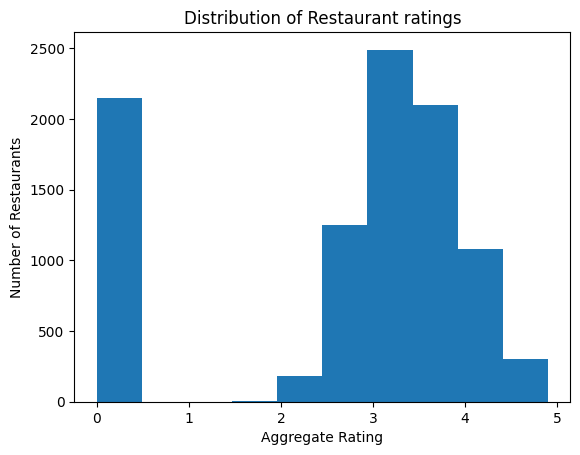

In [10]:
plt.figure()
plt.hist(ratings)
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Restaurant ratings")
plt.show()

In [17]:
votes = df["Votes"].dropna()

average_votes = votes.sum() / votes.count()

print("Average number of votes:---", round(average_votes, 2))

Average number of votes:--- 156.91


## TASK: 2

Task: Cuisine Combination

Identify the most common combinations of
cuisines in the dataset.
Determine if certain cuisine combinations
tend to have higher ratings.

In [18]:
df = df.dropna(subset = ["Cuisines", "Aggregate rating"])

df["Cuisines"] = df["Cuisines"].str.strip()

In [19]:
cuisine_combo_counts = df["Cuisines"].value_counts()

In [20]:
print("Most common cuisine combinations:--")
print(cuisine_combo_counts.head(10))
print()

Most common cuisine combinations:--
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64



In [21]:
combo_ratings = {}

for combo in cuisine_combo_counts.index:
    combo_data = df[df["Cuisines"] == combo]

    if len(combo_data) > 1:
        avg_rating = np.mean(combo_data["Aggregate rating"])
        combo_ratings[combo] = avg_rating

In [26]:
combo_ratings_df = pd.DataFrame( 
    list(combo_ratings.items()),
    columns=["Cuisine Combination", "Average Rating"] )                            

In [27]:
combo_ratings_df = combo_ratings_df.sort_values(
    by = "Average Rating",
    ascending = False
)

In [29]:
print("Cuisine combination with highest average ratings:----")
print(combo_ratings_df.head(10))

Cuisine combination with highest average ratings:----
                       Cuisine Combination  Average Rating
332                      Sunda, Indonesian        4.900000
341                      Filipino, Mexican        4.850000
266  European, Mediterranean, North Indian        4.800000
338                       Chinese, Dim Sum        4.750000
320                   Indian, North Indian        4.733333
278     Mexican, American, Tex-Mex, Burger        4.700000
225                    Brazilian, Bar Food        4.675000
449               Sandwich, Seafood, Cajun        4.650000
401                     American, Desserts        4.650000
542                 Taiwanese, Street Food        4.650000


## TASK:3

Task: Geographic Analysis

Plot the locations of restaurants on a
map using longitude and latitude
coordinates.
Identify any patterns or clusters of
restaurants in specific areas.

In [30]:
df = df.dropna(subset = ["Latitude", "Longitude"])

<function matplotlib.pyplot.show(close=None, block=None)>

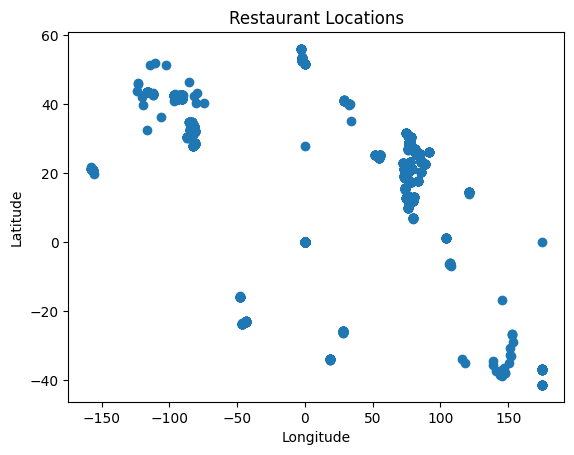

In [31]:
plt.scatter(df["Longitude"], df["Latitude"])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Restaurant Locations")
plt.show

## TASK:4

Task: Restaurant Chains

Identify if there are any restaurant chains
present in the dataset.
Analyze the ratings and popularity of
different restaurant chains.

In [32]:
name_count = df["Restaurant Name"].value_counts()

In [35]:
chains = name_count[name_count > 1]

print("Restaurant Chains:---")
print(chains.head())
print()

Restaurant Chains:---
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Name: count, dtype: int64



In [37]:
for name in chains.index[:5]:
    chain_data = df[df["Restaurant Name"] == name]

    avg_rating = chain_data["Aggregate rating"].mean()
    avg_votes = chain_data["Votes"].mean()

In [38]:
print(name)
print("Average Rating:", round(avg_rating, 2))
print("Average Votes:", round(avg_votes, 2))
print()

McDonald's
Average Rating: 3.34
Average Votes: 110.23



In [39]:
## CONCLUSION...

# "Excellent" restaurants have the highest ratings.
# Ratings decrease from very good to poor.
# Poor-rated restaurants score the lowest.
# "Not rated" does not represent real ratings.
# Rating text matches numeric ratings.